# ATM Predictive Demand Model
### SEANSKIDATA Analytics Portfolio — Project 3 | Python Build

**Business question:** Based on historical transaction patterns, day-of-week behavior, tax season demand spikes, and terminal type — **which ATMs will hit a critical cash threshold in the next 72 hours?**

Standard ATM reporting flags machines that are *already* low. By then the only option is emergency dispatch at 2.5x–4.0x the scheduled cost. This model forecasts forward, scores every machine by operational urgency, and outputs a prioritized dispatch action register.

**Pipeline in this notebook:**

| Stage | Cells | What happens |
|---|---|---|
| 1. Synthetic data generation | 1–4 | 50-ATM master + 18,300-row full-year (2024) transaction time series |
| 2. Burn-rate feature engineering | 5–7 | Rolling averages, day-of-week patterns, burn trend (SQL window-function equivalents) |
| 3. 72-hour forecast | 8 | Forward cash runway projection per machine |
| 4. Composite risk scoring | 9 | Multi-factor priority register (the model's core output) |
| 5. Operations dashboard | 10 | 6-panel Matplotlib view (mirrors the Tableau dashboard) |
| 6. Model validation | 11–12 | December 2024 holdout — MAE / RMSE / MAPE + critical-flag precision/recall |
| 7. Exports | 13 | `atm_master.csv`, `atm_transactions.csv`, `atm_forecast.csv`, dashboard PNG |

> **Why synthetic data:** All data is purpose-built to reflect realistic ATM network operating conditions — regional demand variance, distance-based replenishment economics, tax season demand spikes — without exposing any proprietary or confidential network information. The *patterns* are calibrated from 18+ years of live ATM network operations experience; the *numbers* are generated. That distinction is the honest, defensible framing: the domain logic is real, the records are not.

---
## Cell 1 — Imports & Domain Configuration

**Methodology decision — encode the business rules as named constants, not magic numbers buried in logic.**

- **Why:** Every dictionary below is a *business rule*, not a modeling choice. Cash tolerance by location type, emergency cost multipliers by distance tier, tax season sensitivity by customer mix — these come from operations experience, and isolating them at the top makes each one auditable and easy to defend ("here is the assumption, here is why").
- **Trade-off:** Hard-coded rules are less flexible than learning these weights from data. With a real network you could fit them empirically; with 50 synthetic machines, domain calibration is more honest than pretending to "learn" parameters from data you generated yourself.
- **Alternative considered:** A config file (YAML/JSON). Overkill for a single-notebook portfolio project — inline constants keep the whole model readable top to bottom.
- **Interview answer:** *"I separated domain assumptions from model logic so every operational rule is visible and challengeable. If a reviewer disagrees with casino cash tolerance being Zero, that's a one-line conversation, not a code archaeology exercise."*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

# Reproducibility — every run regenerates the identical dataset
rng = np.random.default_rng(42)

# ---- Calendar ------------------------------------------------------------
# 2024 is a leap year: 50 ATMs x 366 days = 18,300 rows (matches the README spec)
DATES = pd.date_range('2024-01-01', '2024-12-31', freq='D')
N_DAYS = len(DATES)

# ---- Business rules (domain-calibrated, not assumed) ----------------------
# Baseline average daily cash dispensed by location type ($/day)
BASE_DAILY = {'Casino': 40_000, 'Airport': 18_000, 'Stadium': 16_000,
              'Urban': 15_000, 'Mall': 12_000, 'Hospital': 9_000,
              'Tourist': 8_500, 'Retail': 8_200, 'Office': 7_000}

# Cassette capacity ($) — sized so each type holds roughly 5-9 days of
# baseline demand, consistent with real replenishment route economics
CAPACITY = {'Casino': 235_000, 'Airport': 145_000, 'Stadium': 140_000,
            'Urban': 120_000, 'Mall': 110_000, 'Hospital': 85_000,
            'Tourist': 80_000, 'Retail': 80_000, 'Office': 70_000}
CAPACITY_TAX_PROX = 100_000   # upsized cassettes — these machines are known seasonal risks

# Average withdrawal size by location type ($)
AVG_WITHDRAWAL = {'Casino': 185, 'Airport': 125, 'Stadium': 110, 'Mall': 95,
                  'Urban': 90, 'Hospital': 85, 'Tourist': 100, 'Retail': 70, 'Office': 80}

# Cash tolerance — how long a machine can acceptably sit empty.
# A casino cannot tolerate an outage; a suburban office ATM can.
CASH_TOLERANCE = {'Casino': 'Zero', 'Airport': 'Low', 'Stadium': 'Low', 'Hospital': 'Low',
                  'Mall': 'Medium', 'Urban': 'Medium', 'Tourist': 'Medium',
                  'Retail': 'High', 'Office': 'High'}

# Critical threshold (% of capacity) — tighter tolerance = earlier alarm
CRITICAL_THRESHOLD_PCT = {'Zero': 30, 'Low': 25, 'Medium': 20, 'High': 15}

# Revenue impact of one hour of downtime ($/hr) — surcharge + interchange +
# host-relationship cost, scaled by location economics
REVENUE_PER_HOUR = {'Casino': 850, 'Airport': 420, 'Stadium': 380, 'Hospital': 290,
                    'Mall': 240, 'Urban': 210, 'Tourist': 190, 'Office': 160, 'Retail': 120}

# Tax season sensitivity — how strongly refund cash hits each customer mix
TAX_SENSITIVITY = {'Retail': 1.0, 'Urban': 1.0, 'Mall': 0.85, 'Casino': 0.70,
                   'Tourist': 0.60, 'Airport': 0.50, 'Hospital': 0.50,
                   'Stadium': 0.50, 'Office': 0.50}

# Seasonal lift factors (vs May-Oct baseline)
TAX_PEAK_LIFT = 0.52       # Feb 15 - Mar 15: x sensitivity -> +52% Retail/Urban, +36% Casino
TAX_RAMP_LIFT = 0.20       # Jan + Apr: x sensitivity
HOLIDAY_MULT = 1.18        # Nov-Dec: +18% all types
TAX_PROX_PEAK_MULT = 8.55  # tax-proximity machines during peak (observed ~+755% lift)
TAX_PROX_RAMP_MULT = 2.20  # tax-proximity machines during ramp months

# Day-of-week demand profiles (Mon..Sun), normalized so the weekly mean = 1.0.
# Friday/Saturday run 48-62% above Monday — forecasting without this
# systematically underestimates weekend burn.
DOW_STANDARD = np.array([1.00, 0.96, 0.98, 1.08, 1.48, 1.62, 1.18])
DOW_STANDARD = DOW_STANDARD / DOW_STANDARD.mean()
DOW_CASINO = np.array([0.92, 0.88, 0.92, 1.05, 1.50, 1.65, 1.28])
DOW_CASINO = DOW_CASINO / DOW_CASINO.mean()

DAILY_NOISE_SIGMA = 0.07   # lognormal day-to-day variation (~7%)

print(f'Calendar: {DATES[0].date()} -> {DATES[-1].date()} ({N_DAYS} days)')
print(f'Target dataset size: 50 ATMs x {N_DAYS} days = {50*N_DAYS:,} rows')

Calendar: 2024-01-01 -> 2024-12-31 (366 days)
Target dataset size: 50 ATMs x 366 days = 18,300 rows


---
## Cell 2 — `atm_master`: the 50-Machine Network

**Methodology decisions:**

1. **`terminal_type` is *derived* from `distance_from_branch_miles` with `pd.cut`** — the Python equivalent of a SQL `CASE WHEN` on a continuous variable. Distance is the raw fact; the Local / Remote / Over The Road classification is the operational rule layered on top (`<25` / `25–99` / `100+` miles). Deriving it (rather than typing it in) means the classification can never disagree with the distance — one source of truth.
2. **`np.select` maps terminal type → emergency multiplier** (2.5x / 3.0x / 4.0x). This is the discrete `CASE WHEN` pattern: explicit condition list, explicit choice list, explicit default. More readable than nested `np.where` once you pass two branches.
3. **Five tax-service-proximity machines are flagged in the master**, not detected from transactions. In the real operation this knowledge came from field intelligence — a route tech noticing the H&R Block next door — not from a query. Modeling it as a master-data attribute is faithful to how the insight actually arrives.
4. **Geography is Houston-anchored** with the casino corridor (Tunica, Laughlin, Biloxi, Shreveport, Lake Charles) at 92–156 miles — the distances that drive the entire economic argument of this model.

**Interview answer:** *"Terminal type, tolerance, and revenue impact are all functions of facts in the master table. I never hand-enter a derived field — if the distance changes, the classification and the emergency cost re-derive themselves."*

In [2]:
# (atm_num, location_name, location_type, distance_from_branch_miles, tax_service_proximity)
ATM_RECORDS = [
    ( 1, 'Downtown Main St Branch Lobby', 'Urban',     2, False),
    ( 2, 'Galleria Mall Level 1',         'Mall',      8, False),
    ( 3, 'IAH Airport Terminal A',        'Airport',  18, False),
    ( 4, 'IAH Airport Terminal B',        'Airport',  18, False),
    ( 5, 'Hobby Airport Concourse',       'Airport',  11, False),
    ( 6, 'NRG Stadium North Gate',        'Stadium',   6, False),
    ( 7, 'Tunica Casino MS',              'Casino',  142, False),
    ( 8, 'Laughlin Casino NV',            'Casino',  156, False),
    ( 9, 'Biloxi Casino MS',              'Casino',   92, False),
    (10, 'Shreveport Casino LA',          'Casino',  144, False),
    (11, 'Texas Medical Center Pavilion', 'Hospital',  4, False),
    (12, 'Heights Retail Plaza',          'Retail',    7, True ),
    (13, 'Montrose Corner Store',         'Retail',    5, False),
    (14, 'Midtown Urban Market',          'Urban',     3, False),
    (15, 'EaDo Warehouse District',       'Urban',     4, False),
    (16, 'River Oaks Shopping Center',    'Retail',    9, False),
    (17, 'Memorial City Mall',            'Mall',     14, False),
    (18, 'Katy Mills Mall',               'Mall',     28, False),
    (19, 'Gulfgate Center',               'Retail',    8, True ),
    (20, 'Pasadena Strip Center',         'Retail',   16, False),
    (21, 'Baytown Plaza',                 'Retail',   29, False),
    (22, 'Sugar Land Town Square',        'Urban',    22, False),
    (23, 'The Woodlands Market',          'Urban',    31, False),
    (24, 'Conroe Outlet Center',          'Retail',   42, False),
    (25, 'Spring Crossing Plaza',         'Retail',   26, True ),
    (26, 'Humble Atascocita Center',      'Retail',   24, False),
    (27, 'Pearland Parkway Shops',        'Retail',   18, False),
    (28, 'League City Marketplace',       'Retail',   27, False),
    (29, 'Galveston Seawall Kiosk',       'Tourist',  52, False),
    (30, 'Galveston Strand District',     'Tourist',  53, False),
    (31, 'Texas City Center',             'Retail',   41, False),
    (32, 'Beaumont Medical Plaza',        'Hospital', 84, False),
    (33, 'Beaumont Eastex Plaza',         'Retail',   86, True ),
    (34, 'Port Arthur Center',            'Retail',  102, False),
    (35, 'Lufkin Crossroads',             'Retail',  118, False),
    (36, 'College Station Northgate',     'Urban',    97, False),
    (37, 'Brenham Town Center',           'Retail',   72, False),
    (38, 'Lake Charles Casino LA',        'Casino',  138, False),
    (39, 'Huntsville Square',             'Retail',   70, False),
    (40, 'Bay City Center',               'Retail',   81, False),
    (41, 'Rosenberg Plaza',               'Retail',   34, True ),
    (42, 'Angleton Courthouse Square',    'Retail',   44, False),
    (43, 'Lake Jackson Center',           'Retail',   54, False),
    (44, 'Cypress Towne Lake',            'Retail',   27, False),
    (45, 'Tomball Main Street',           'Retail',   33, False),
    (46, 'Kingwood Town Center',          'Retail',   26, False),
    (47, 'Victoria Mall',                 'Mall',    125, False),
    (48, 'El Campo Plaza',                'Retail',   76, False),
    (49, 'Palacios Waterfront',           'Tourist', 110, False),
    (50, 'Westchase Office Tower',        'Office',   12, False),
]

atm_master = pd.DataFrame(ATM_RECORDS,
    columns=['atm_num', 'location_name', 'location_type',
             'distance_from_branch_miles', 'tax_service_proximity'])
atm_master['atm_id'] = atm_master['atm_num'].map(lambda n: f'ATM{n:03d}')

# CASE WHEN equivalent #1 -- pd.cut: continuous distance -> operational tier
# Local < 25mi | Remote 25-99mi | Over The Road 100+mi
atm_master['terminal_type'] = pd.cut(
    atm_master['distance_from_branch_miles'],
    bins=[0, 25, 100, np.inf],
    labels=['Local', 'Remote', 'Over The Road'],
    right=False).astype(str)

# CASE WHEN equivalent #2 -- np.select: discrete tier -> emergency cost multiplier
atm_master['emergency_multiplier'] = np.select(
    [atm_master['terminal_type'] == 'Over The Road',
     atm_master['terminal_type'] == 'Remote',
     atm_master['terminal_type'] == 'Local'],
    [4.0, 3.0, 2.5])

# Business-rule lookups (dict .map = CASE WHEN on a categorical key)
atm_master['cash_tolerance'] = atm_master['location_type'].map(CASH_TOLERANCE)
atm_master['revenue_impact_per_hour'] = atm_master['location_type'].map(REVENUE_PER_HOUR)
atm_master['cash_capacity_dollars'] = np.where(
    atm_master['tax_service_proximity'],
    CAPACITY_TAX_PROX,
    atm_master['location_type'].map(CAPACITY))

atm_master = atm_master[['atm_id', 'location_name', 'location_type', 'terminal_type',
                         'distance_from_branch_miles', 'cash_capacity_dollars',
                         'cash_tolerance', 'emergency_multiplier',
                         'revenue_impact_per_hour', 'tax_service_proximity']]

print(atm_master['terminal_type'].value_counts().to_string(), '\n')
print('Tax-service-proximity machines:',
      ', '.join(atm_master.loc[atm_master.tax_service_proximity, 'atm_id']))
atm_master.head(12)

terminal_type
Remote           23
Local            19
Over The Road     8 

Tax-service-proximity machines: ATM012, ATM019, ATM025, ATM033, ATM041


,atm_id,location_name,location_type,terminal_type,distance_from_branch_miles,cash_capacity_dollars,cash_tolerance,emergency_multiplier,revenue_impact_per_hour,tax_service_proximity
0,ATM001,Downtown Main St Branch Lobby,Urban,Local,2,120000,Medium,2.5,210,False
1,ATM002,Galleria Mall Level 1,Mall,Local,8,110000,Medium,2.5,240,False
2,ATM003,IAH Airport Terminal A,Airport,Local,18,145000,Low,2.5,420,False
3,ATM004,IAH Airport Terminal B,Airport,Local,18,145000,Low,2.5,420,False
4,ATM005,Hobby Airport Concourse,Airport,Local,11,145000,Low,2.5,420,False
5,ATM006,NRG Stadium North Gate,Stadium,Local,6,140000,Low,2.5,380,False
6,ATM007,Tunica Casino MS,Casino,Over The Road,142,235000,Zero,4.0,850,False
7,ATM008,Laughlin Casino NV,Casino,Over The Road,156,235000,Zero,4.0,850,False
8,ATM009,Biloxi Casino MS,Casino,Remote,92,235000,Zero,3.0,850,False
9,ATM010,Shreveport Casino LA,Casino,Over The Road,144,235000,Zero,4.0,850,False


---
## Cell 3 — Generate the 18,300-Row Transaction Time Series

This is the heart of the synthetic dataset. Each ATM-day's demand is built as:

```
demand = base_daily(type) x dow_factor(weekday) x seasonal_multiplier(date, type, prox) x lognormal_noise(sigma=7%)
```

then run through a **sequential cash-balance simulation** with scheduled replenishment.

**Methodology decisions:**

1. **Multiplicative demand model.** Demand effects in cash logistics compound — a Saturday *during* tax peak is busier than either effect alone. Multiplying factors captures that; an additive model wouldn't. This mirrors how seasonal indices are applied in real cash forecasting.
2. **Lognormal noise, not normal.** Daily cash demand can't go negative and has a longer right tail (one busy day hurts more than one quiet day helps). Lognormal respects both. σ = 7% is calibrated to typical day-over-day variation on a stable terminal.
3. **Balance simulation is a per-machine loop, not vectorized.** Cash balance has *state* — today's balance depends on yesterday's balance and refill decisions. A loop is the honest expression of a stateful process, runs in well under a second at this scale, and is far easier to defend line-by-line in an interview than a clever segmented-cumsum trick. **Trade-off:** wouldn't scale to millions of machine-days; at 18,300 rows, clarity wins.
4. **Replenishment runs on fixed route cycles with operational uplifts** — exactly how real networks operate:
   - Standard machines: fixed cycle (4–7 days depending on type)
   - **Tax peak (Feb 15–Mar 15): all route cycles halve** — this is what ops teams actually do when refund season hits
   - **Tax-proximity machines: daily service during peak, every 3 days during ramp** — these five machines consume an outsized share of route capacity for 28 days
   - **Zero-tolerance (casino) machines: 4-day cycles during Nov–Dec holiday lift**
5. **`dispensed = min(demand, balance)`** — a machine can't dispense cash it doesn't have. Where demand exceeds balance, the shortfall is a *stockout*, which is precisely the failure mode the model exists to prevent.

**Interview answer:** *"I didn't generate random numbers and call them transactions. I generated demand from a structural model — base rate by location economics, day-of-week shape, seasonal lift by customer mix — then simulated the cash position through a replenishment policy. The dataset has the failure modes of a real network because it's produced by the mechanics of a real network."*

In [3]:
def seasonal_multiplier(date, location_type, tax_prox):
    # CASE WHEN equivalent #3 -- the seasonal calendar as explicit branches
    m, d = date.month, date.day
    is_peak = (m == 2 and d >= 15) or (m == 3 and d <= 15)   # refund window
    if is_peak:
        return TAX_PROX_PEAK_MULT if tax_prox else 1 + TAX_PEAK_LIFT * TAX_SENSITIVITY[location_type]
    if m in (1, 4):                                          # ramp months
        return TAX_PROX_RAMP_MULT if tax_prox else 1 + TAX_RAMP_LIFT * TAX_SENSITIVITY[location_type]
    if m in (11, 12):                                        # holiday season
        return HOLIDAY_MULT
    return 1.0                                               # May-Oct baseline

# Replenishment route assignments.
# Named "anchor" machines carry fixed cycles/offsets so the end-of-year network
# state lands mid-cycle (a realistic operating snapshot); the rest are randomized.
FIXED_ROUTES = {                       # atm_id: (cycle_days, offset)
    'ATM003': (6, 0), 'ATM004': (6, 0), 'ATM005': (6, 0),   # airports
    'ATM006': (7, 2),                                        # NRG Stadium
    'ATM007': (5, 2), 'ATM008': (5, 2), 'ATM009': (5, 2),   # casinos
    'ATM010': (5, 2), 'ATM038': (5, 2),
    'ATM047': (7, 2), 'ATM049': (7, 2),                      # Victoria / Palacios
}
ANCHOR_IDS = set(FIXED_ROUTES)

def route_for(row):
    if row.atm_id in FIXED_ROUTES:
        return FIXED_ROUTES[row.atm_id]
    cycle = int(rng.choice([4, 5, 6] if row.location_type == 'Urban' else [5, 6, 7]))
    return cycle, int(rng.integers(0, cycle))

def is_refill_day(idx, date, cycle, offset, tolerance, tax_prox):
    m, d = date.month, date.day
    is_peak = (m == 2 and d >= 15) or (m == 3 and d <= 15)
    if tax_prox and is_peak:
        return True                                   # daily service in refund window
    if tax_prox and m in (1, 4):
        return (idx - offset) % 3 == 0                # elevated ramp service
    if is_peak:
        return (idx - offset) % ceil(cycle / 2) == 0  # network-wide tax-season route uplift
    if tolerance == 'Zero' and m in (11, 12):
        return (idx - offset) % 4 == 0                # holiday uplift for zero-tolerance units
    return (idx - offset) % cycle == 0

records = []
for atm in atm_master.itertuples(index=False):
    cycle, offset = route_for(atm)
    base = BASE_DAILY[atm.location_type]
    if atm.atm_id not in ANCHOR_IDS:                  # per-site economics vary +/-8%
        base *= rng.uniform(0.92, 1.08)
    dow_profile = DOW_CASINO if atm.location_type == 'Casino' else DOW_STANDARD
    withdrawal = AVG_WITHDRAWAL[atm.location_type]

    balance = atm.cash_capacity_dollars               # start the year fully loaded
    for idx, date in enumerate(DATES):
        refilled = is_refill_day(idx, date, cycle, offset,
                                 atm.cash_tolerance, atm.tax_service_proximity)
        if refilled:
            balance = atm.cash_capacity_dollars       # refill at start of business day

        demand = (base
                  * dow_profile[date.dayofweek]
                  * seasonal_multiplier(date, atm.location_type, atm.tax_service_proximity)
                  * rng.lognormal(0, DAILY_NOISE_SIGMA))
        dispensed = min(demand, balance)              # can't dispense cash it doesn't hold
        balance -= dispensed

        avg_wd = withdrawal * rng.normal(1, 0.03)
        records.append((atm.atm_id, date, int(round(dispensed / avg_wd)),
                        round(avg_wd, 2), round(dispensed, 2), round(balance, 2),
                        refilled))

atm_transactions = pd.DataFrame(records, columns=[
    'atm_id', 'transaction_date', 'daily_transactions', 'avg_withdrawal_amount',
    'daily_cash_dispensed', 'cash_balance_eod', 'was_replenished'])

assert len(atm_transactions) == 18_300, 'Row count must match the README spec'
print(f'atm_transactions: {len(atm_transactions):,} rows '
      f'({atm_transactions.atm_id.nunique()} ATMs x {N_DAYS} days)')
atm_transactions.head(8)

atm_transactions: 18,300 rows (50 ATMs x 366 days)


,atm_id,transaction_date,daily_transactions,avg_withdrawal_amount,daily_cash_dispensed,cash_balance_eod,was_replenished
0,ATM001,2024-01-01,171,92.5,"15,843.0","104,157.0",False
1,ATM001,2024-01-02,146,86.5,"12,588.8","91,568.2",False
2,ATM001,2024-01-03,167,89.2,"14,864.0","76,704.2",False
3,ATM001,2024-01-04,185,87.7,"16,215.8","103,784.2",True
4,ATM001,2024-01-05,257,92.1,"23,660.3","80,123.9",False
5,ATM001,2024-01-06,263,93.0,"24,465.1","55,658.8",False
6,ATM001,2024-01-07,209,87.7,"18,328.2","37,330.7",False
7,ATM001,2024-01-08,176,87.4,"15,425.3","104,574.7",True


---
## Cell 4 — Dataset Integrity Checks: Does the Data Contain the Patterns the Model Must Find?

**Methodology decision — validate the generator before modeling anything.** With synthetic data the burden of proof is *higher*, not lower: if the seasonal and day-of-week structure isn't measurably present, every downstream "insight" is fiction. These checks replay README Query 4 (tax season lift) and Query 5 (day-of-week index) in pandas — `groupby` + pivot is the `GROUP BY` + `CASE WHEN` season bucketing from the SQL layer.

What must be true:
- **Tax peak lift:** Retail/Urban ≈ +50–55%, Casino ≈ +35%, Mall ≈ +42% vs May–Oct baseline
- **Tax-proximity machines:** ≈ +750% at peak — routine all year, network-leading for 28 days
- **Day-of-week:** Friday/Saturday ≈ 42–73% above Monday

**A subtle trap this cell defends against:** if the five tax-proximity machines are left inside the Retail average, the Retail peak lift inflates to ~+190% and the by-type table contradicts the +52% design target. Segment contamination — one small subpopulation distorting its parent category — is exactly the kind of error that survives a casual review and dies in an interview.

**Interview answer:** *"The first thing I modeled was nothing — I audited the dataset against the operational patterns it's supposed to carry. If you can't show me the tax spike in a groupby, you have no business forecasting it."*

In [4]:
txn = atm_transactions.merge(
    atm_master[['atm_id', 'location_type', 'tax_service_proximity']], on='atm_id')

# CASE WHEN equivalent #4 -- np.select assigns each date to a season bucket
m, d = txn.transaction_date.dt.month, txn.transaction_date.dt.day
txn['season'] = np.select(
    [((m == 2) & (d >= 15)) | ((m == 3) & (d <= 15)),
     m.isin([1, 4]),
     m.isin([11, 12])],
    ['Tax Season Peak', 'Tax Season Ramp', 'Holiday'],
    default='Baseline')

# Exclude tax-proximity machines here so the by-type lifts are clean -- leaving
# them in silently inflates the Retail row to ~+190% and misstates the story.
# (They get their own table below, which is the point.)
seasonal = (txn[~txn.tax_service_proximity]
               .groupby(['location_type', 'season'])['daily_cash_dispensed']
               .mean().unstack('season')
               [['Baseline', 'Tax Season Ramp', 'Tax Season Peak', 'Holiday']])
seasonal['peak_lift_%'] = (seasonal['Tax Season Peak'] / seasonal['Baseline'] - 1) * 100
print('=== Seasonal demand by location type (tax-proximity machines excluded) ===')
print(seasonal.round(0).to_string(), '\n')

prox = (txn[txn.location_type == 'Retail']
        .groupby(['tax_service_proximity', 'season'])['daily_cash_dispensed']
        .mean().unstack('season')[['Baseline', 'Tax Season Peak']])
prox['lift_%'] = (prox['Tax Season Peak'] / prox['Baseline'] - 1) * 100
prox.index = ['Retail (standard)', 'Tax Service Proximity']
print('=== The Tax Service Proximity Effect ===')
print(prox.round(0).to_string(), '\n')

dow = (txn.assign(dow=txn.transaction_date.dt.day_name())
          .groupby('dow')['daily_cash_dispensed'].mean()
          .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))
print('=== Day-of-week demand index (network, Monday = 1.00) ===')
print((dow / dow['Monday']).round(2).to_string())

=== Seasonal demand by location type (tax-proximity machines excluded) ===
season         Baseline  Tax Season Ramp  Tax Season Peak  Holiday  peak_lift_%
location_type                                                                  
Airport        18,042.0         19,452.0         23,167.0 21,364.0         28.0
Casino         40,262.0         43,955.0         54,876.0 47,470.0         36.0
Hospital        8,837.0          9,557.0         11,234.0 10,629.0         27.0
Mall           11,881.0         13,700.0         17,283.0 14,002.0         45.0
Office          6,466.0          7,022.0          8,335.0  7,595.0         29.0
Retail          8,073.0          9,541.0         12,369.0  9,551.0         53.0
Stadium        16,067.0         16,963.0         20,367.0 18,844.0         27.0
Tourist         8,606.0          9,516.0         11,371.0 10,347.0         32.0
Urban          15,128.0         17,846.0         23,036.0 17,938.0         52.0 

=== The Tax Service Proximity Effect ===
se

---
## Cell 5 — Rolling Burn-Rate Features (SQL Window Functions in Pandas)

This cell replicates README Query 1 / Query 2's window functions. The translation table is the interview gold here:

| SQL (production layer) | Pandas (this notebook) |
|---|---|
| `AVG(x) OVER (PARTITION BY atm_id ORDER BY date ROWS BETWEEN 29 PRECEDING AND CURRENT ROW)` | `groupby('atm_id')[x].transform(lambda s: s.rolling(30, min_periods=1).mean())` |
| `AVG(x) OVER (PARTITION BY atm_id ... ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)` | `.rolling(7, min_periods=1).mean()` |
| `AVG(x) OVER (PARTITION BY atm_id ... ROWS BETWEEN 13 PRECEDING AND 7 PRECEDING)` | `.rolling(7, min_periods=1).mean().shift(7)` |
| `AVG(x) OVER (PARTITION BY atm_id, DAYOFWEEK(date))` | `groupby(['atm_id','dow']).transform('mean')` |

**Methodology decisions:**

1. **7-day rolling mean is the operational burn rate.** Why 7? It's the shortest window that contains exactly one full weekly cycle, so Fri/Sat peaks are always represented exactly once — a 5-day window would whipsaw depending on which weekdays it covers; a 30-day window reacts too slowly to a demand regime change. The 30-day average is kept as the *stability* reference.
2. **`min_periods=1` instead of dropping warm-up rows.** Early-January rows compute on partial windows rather than returning NaN. Trade-off: the first week's burn estimate is noisier — acceptable because every operational decision in this model happens at year-end, 51 weeks past warm-up.
3. **Sort before rolling.** `rolling()` is order-dependent; SQL forces ordering inside the window clause, pandas makes *you* responsible. Forgetting the sort is the #1 silent-corruption bug in time-series pandas.

**Interview answer:** *"The Python model and the SQL layer are the same analytics in two dialects. Rolling burn is a 7-day window because cash demand is weekly-periodic — any window that doesn't hold exactly one cycle either misses the weekend or double-counts it."*

In [5]:
txn_features = atm_transactions.sort_values(['atm_id', 'transaction_date']).copy()
txn_features['day_of_week_num'] = txn_features.transaction_date.dt.dayofweek
txn_features['day_of_week'] = txn_features.transaction_date.dt.day_name()

g = txn_features.groupby('atm_id')['daily_cash_dispensed']

# Rolling 30-day average -- long-horizon stability reference
txn_features['rolling_30d_avg_burn'] = g.transform(
    lambda s: s.rolling(30, min_periods=1).mean())

# Rolling 7-day average -- the operational burn rate (one full weekly cycle)
txn_features['rolling_7d_burn'] = g.transform(
    lambda s: s.rolling(7, min_periods=1).mean())

# Prior week's 7-day average -- LAG-style reference for trend detection
txn_features['prior_week_avg_burn'] = g.transform(
    lambda s: s.rolling(7, min_periods=1).mean().shift(7))

# Day-of-week average per machine -- PARTITION BY atm_id, DAYOFWEEK(date)
txn_features['dow_avg_burn'] = (
    txn_features.groupby(['atm_id', 'day_of_week_num'])['daily_cash_dispensed']
                .transform('mean'))

txn_features[['atm_id', 'transaction_date', 'day_of_week', 'daily_cash_dispensed',
              'rolling_7d_burn', 'rolling_30d_avg_burn', 'dow_avg_burn']].tail(5)

,atm_id,transaction_date,day_of_week,daily_cash_dispensed,rolling_7d_burn,rolling_30d_avg_burn,dow_avg_burn
18295,ATM050,2024-12-27,Friday,"8,830.7","7,450.2","7,572.3","8,599.4"
18296,ATM050,2024-12-28,Saturday,"11,140.5","7,453.6","7,720.8","9,352.2"
18297,ATM050,2024-12-29,Sunday,"8,833.3","7,600.6","7,719.1","6,890.6"
18298,ATM050,2024-12-30,Monday,"6,179.9","7,559.4","7,594.1","5,897.4"
18299,ATM050,2024-12-31,Tuesday,"6,011.7","7,651.0","7,549.7","5,595.7"


---
## Cell 6 — Burn Trend: Is Demand Accelerating?

**Methodology decision — a binary trend flag with a 20% materiality gate, not a regression slope.**

- **Why:** Ops dispatchers need a yes/no signal: *is this machine burning meaningfully faster than last week?* Comparing this week's 7-day burn to last week's, with a 1.20x threshold, filters ordinary noise (daily σ ≈ 7% → weekly means rarely drift 20% by chance) while catching genuine regime changes — a new employer payroll nearby, an event calendar shift, a competing ATM going dark.
- **Trade-off:** A threshold flag loses magnitude information (25% acceleration and 80% acceleration look identical). The composite risk score compensates: acceleration shows up there through the falling `days_until_empty` anyway, so the flag is for human triage, not for the math.
- **Alternative considered:** Linear regression slope per machine over 14 days — more sensitive, but harder to explain to a route scheduler at 6am, and sensitivity wasn't the constraint.
- **`np.where` is the two-branch `CASE WHEN`** — this exact expression appears in Query 2 as `CASE WHEN rolling_7d_burn > prior_week_avg_burn * 1.20 THEN 'ACCELERATING' ELSE 'STABLE' END`.

In [6]:
# CASE WHEN equivalent #5 -- np.where for the two-branch case
txn_features['burn_trend'] = np.where(
    txn_features['rolling_7d_burn'] > txn_features['prior_week_avg_burn'] * 1.20,
    'ACCELERATING', 'STABLE')

latest = txn_features[txn_features.transaction_date == txn_features.transaction_date.max()]
print('Burn trend across the network on', txn_features.transaction_date.max().date(), ':')
print(latest['burn_trend'].value_counts().to_string())

Burn trend across the network on 2024-12-31 :
burn_trend
STABLE    50


---
## Cell 7 — Join Transactions to the Master Table  ⚠️ *(the KeyError fix lives here)*

**The original bug:** the column list used to subset `atm_master` before the merge **did not include `terminal_type`**. The merge itself succeeded silently — pandas happily joins whatever columns you hand it — and the pipeline only blew up downstream, when the risk-scoring `np.select` asked for `burn['terminal_type']` and raised `KeyError: 'terminal_type'`.

**The fix:** `terminal_type` is now explicitly in `MASTER_COLS`, and an `assert` immediately after the merge verifies every column the scoring layer depends on. **The lesson worth telling in an interview:** the failure surfaced two cells away from its cause. A SQL `SELECT` that omits a column fails *at the reference point with a clear message*; a pandas subset that omits a column fails *wherever the column is first touched*. The defense is to validate the contract at the merge boundary, not to trust it.

**Other decisions in this cell:**
- **Inner join on `atm_id`** — mirrors Query 1's `INNER JOIN atm_master l ON t.atm_id = l.atm_id`. Both tables are generated from the same master so no rows can drop, and the row-count assert proves it. In production this assert is the canary for orphaned terminal IDs.
- **Subset the master to needed columns *before* merging** — keeps the working frame lean and makes the data contract explicit. That explicitness is exactly what made the original omission a one-line fix once located.

In [7]:
# THE FIX: 'terminal_type' is present in the master column list.
# (Its earlier omission caused: KeyError: 'terminal_type' in the risk-scoring cell.)
MASTER_COLS = ['atm_id', 'location_name', 'location_type', 'terminal_type',
               'cash_tolerance', 'cash_capacity_dollars', 'distance_from_branch_miles',
               'tax_service_proximity', 'emergency_multiplier', 'revenue_impact_per_hour']

burn = txn_features.merge(atm_master[MASTER_COLS], on='atm_id', how='inner')

# Validate the merge contract at the boundary -- fail HERE, loudly,
# not two cells downstream inside np.select.
REQUIRED = {'terminal_type', 'cash_tolerance', 'cash_capacity_dollars',
            'revenue_impact_per_hour', 'tax_service_proximity'}
missing = REQUIRED - set(burn.columns)
assert not missing, f'Merge contract broken -- missing columns: {missing}'
assert len(burn) == len(txn_features), 'Inner join dropped rows -- orphaned atm_ids exist'

print(f'Merged frame: {len(burn):,} rows x {burn.shape[1]} columns -- contract verified.')
burn[['atm_id', 'transaction_date', 'location_name', 'terminal_type', 'cash_tolerance',
      'daily_cash_dispensed', 'rolling_7d_burn', 'cash_balance_eod']].tail(3)

Merged frame: 18,300 rows x 23 columns -- contract verified.


,atm_id,transaction_date,location_name,terminal_type,cash_tolerance,daily_cash_dispensed,rolling_7d_burn,cash_balance_eod
18297,ATM050,2024-12-29,Westchase Office Tower,Local,High,"8,833.3","7,600.6","23,264.2"
18298,ATM050,2024-12-30,Westchase Office Tower,Local,High,"6,179.9","7,559.4","63,820.1"
18299,ATM050,2024-12-31,Westchase Office Tower,Local,High,"6,011.7","7,651.0","57,808.4"


---
## Cell 8 — The 72-Hour Cash Runway Forecast

For every machine, project the cash position 72 hours forward from the latest balance:

```
projected_72hr_balance = cash_balance_eod - (rolling_7d_burn x 3)
days_until_empty       = cash_balance_eod / rolling_7d_burn
```

**Methodology decisions:**

1. **Why 72 hours?** It's the operational decision window, not a statistical choice. A scheduled route can be inserted with ~2–3 days' notice; inside 72 hours your only remaining option is emergency dispatch at 2.5x–4.0x cost. Forecasting further out adds error without adding decisions; forecasting shorter forfeits the cheap option.
2. **Why `rolling_7d_burn x 3` and not a day-of-week-aware projection?** Deliberate parity with the SQL layer (Query 2 uses exactly this expression), and transparency: a dispatcher can verify the number on a napkin. **Trade-off acknowledged:** a flat multiplier underestimates a forecast window that contains Fri/Sat. Cell 11's validation quantifies what the smarter DOW-aware model buys you — keeping the production rule simple is a choice made *with* the evidence, not in ignorance of it.
3. **`days_until_empty` is the forward-looking inversion of a balance snapshot.** "Balance = $44K" is a fact; "0.9 days of runway" is a decision. Same data, different framing — and the framing is the product.
4. **Critical thresholds scale with cash tolerance** (Zero=30% of capacity, Low=25%, Medium=20%, High=15%). A casino alarms earlier *by design*: the cost of being wrong is categorically higher. This is `CASE WHEN` via `.map()` on the tolerance key.

**Interview answer:** *"72 hours isn't a modeling parameter, it's the price boundary — it's the last moment a scheduled truck is still an option. The model exists to keep decisions on the cheap side of that line."*

In [8]:
FORECAST_DATE = burn['transaction_date'].max()

forecast = (burn[burn.transaction_date == FORECAST_DATE]
            .rename(columns={'cash_balance_eod': 'current_balance',
                             'rolling_7d_burn': 'avg_daily_burn'})
            [['atm_id', 'location_name', 'location_type', 'terminal_type',
              'cash_tolerance', 'cash_capacity_dollars', 'distance_from_branch_miles',
              'tax_service_proximity', 'emergency_multiplier', 'revenue_impact_per_hour',
              'current_balance', 'avg_daily_burn', 'burn_trend']]
            .reset_index(drop=True))

# Forward projection -- parity with SQL Query 2
forecast['projected_72hr_balance'] = forecast.current_balance - forecast.avg_daily_burn * 3
forecast['projected_pct_remaining'] = (
    forecast.projected_72hr_balance / forecast.cash_capacity_dollars * 100).round(1)
forecast['days_until_empty'] = (
    forecast.current_balance / forecast.avg_daily_burn.replace(0, np.nan)).round(1)

# Tolerance-scaled critical thresholds (CASE WHEN via .map)
forecast['critical_threshold_pct'] = forecast.cash_tolerance.map(CRITICAL_THRESHOLD_PCT)
forecast['risk_status'] = np.where(
    forecast.projected_pct_remaining <= forecast.critical_threshold_pct,
    'CRITICAL', 'ELEVATED')

forecast['revenue_at_risk_72hr'] = forecast.revenue_impact_per_hour * 72

print(f'Forecast as of {FORECAST_DATE.date()} -- 72-hour window ahead\n')
print(forecast.risk_status.value_counts().to_string(), '\n')
forecast.nsmallest(8, 'days_until_empty')[
    ['atm_id', 'location_name', 'terminal_type', 'cash_tolerance',
     'current_balance', 'avg_daily_burn', 'days_until_empty',
     'projected_pct_remaining', 'risk_status']]

Forecast as of 2024-12-31 -- 72-hour window ahead

risk_status
CRITICAL    25
ELEVATED    25 



,atm_id,location_name,terminal_type,cash_tolerance,current_balance,avg_daily_burn,days_until_empty,projected_pct_remaining,risk_status
2,ATM003,IAH Airport Terminal A,Local,Low,"11,752.8","21,521.9",0.5,-36.4,CRITICAL
46,ATM047,Victoria Mall,Over The Road,Medium,"7,828.3","14,596.0",0.5,-32.7,CRITICAL
4,ATM005,Hobby Airport Concourse,Local,Low,"13,762.0","21,520.1",0.6,-35.0,CRITICAL
5,ATM006,NRG Stadium North Gate,Local,Low,"11,770.8","18,318.5",0.6,-30.8,CRITICAL
37,ATM038,Lake Charles Casino LA,Over The Road,Zero,"30,747.4","50,224.6",0.6,-51.0,CRITICAL
7,ATM008,Laughlin Casino NV,Over The Road,Zero,"39,261.6","49,183.1",0.8,-46.1,CRITICAL
6,ATM007,Tunica Casino MS,Over The Road,Zero,"44,874.8","47,713.5",0.9,-41.8,CRITICAL
8,ATM009,Biloxi Casino MS,Remote,Zero,"42,608.4","46,223.8",0.9,-40.9,CRITICAL


---
## Cell 9 — Composite Risk Score & the Operational Action Register

The single number that replaces volume-based ranking:

```
Risk Score =
  Cash Depletion Weight   (0-60 pts -- how far below the 30% anchor, x2, clipped)
+ Terminal Type Weight    (OTR=40, Remote=20, Local=5)
+ Cash Tolerance Weight   (Zero=35, Low=20, Medium=10, High=0)
+ Revenue Impact Weight   (hourly revenue impact / 20)
+ Tax Proximity Premium   (+25 during the Feb 15 - Mar 15 peak)
```

**Methodology decisions — and these are the ones interviewers will push on:**

1. **Why an additive point system instead of a trained model?** Three reasons. *Explainability:* a dispatcher can decompose any score into its causes in seconds — "177 because depletion is maxed, it's Over The Road, and it's zero-tolerance." *No training labels:* there is no historical dataset of "correct priorities" to fit against; the weights encode the cost structure ops already knows. *Auditability:* changing a weight is a governance decision, not a retrain. **Trade-off:** the weights are judgment, not estimation — defensible judgment, stated openly.
2. **Why is depletion capped at 60 points (`np.clip`)?** Without the cap, a deeply negative projection would drown every other factor and the register would collapse back into "sort by emptiness" — exactly the one-dimensional ranking this model exists to replace. The cap forces *distance, tolerance, and revenue* to break ties among machines that are all going empty, which is the actual dispatch decision. (Note: the SQL version uses `GREATEST(0, ...)` without an upper cap — the Python cap is the documented formula; worth aligning the SQL when convenient.)
3. **Why a fixed 30% anchor for depletion rather than each machine's own threshold?** Comparability. Depletion points must mean the same thing across the network; tolerance differences already enter through their own 0–35 pt term. Using per-machine anchors would double-count tolerance.
4. **Terminal type (40) outweighs tolerance (35) slightly** because distance is irreversible at dispatch time — you can negotiate an outage with a merchant, you cannot negotiate 156 miles with a courier.
5. **The +25 tax-proximity premium is date-gated** — it only fires Feb 15–Mar 15. On a December forecast date it contributes 0, which you can verify in the output. The flag costs nothing for 11 months and reclassifies the right five machines for the 28 days that matter.
6. **Tiers via `pd.cut`** (LOW <60, MEDIUM 60–99, HIGH 100–139, CRITICAL 140+), **dispatch action via `.apply`** — the last two CASE WHEN equivalents, and ranking sorts by score with `days_until_empty` as the tiebreaker — the `ROW_NUMBER() OVER (ORDER BY score DESC, runway ASC)` pattern, because a dispatcher cannot action a four-way tie. `rank(pct=True)` reproduces `PERCENT_RANK()`.

**Interview answer:** *"The casino scores 177 with average volume because the score prices the cost of being wrong, not the popularity of the machine. Tunica at 142 miles with zero tolerance and $850/hour at stake simply cannot be allowed to fail — the score is the economics, made sortable."*

In [9]:
f = forecast

# Component 1 -- cash depletion (np.clip = GREATEST(0,...) with a documented 60-pt cap)
f['pts_depletion'] = np.clip((30 - f.projected_pct_remaining) * 2, 0, 60)

# Component 2 -- terminal type (np.select CASE WHEN). This line is the one that
# raised KeyError before terminal_type was restored to the Cell 7 merge.
f['pts_terminal'] = np.select(
    [f.terminal_type == 'Over The Road', f.terminal_type == 'Remote', f.terminal_type == 'Local'],
    [40, 20, 5])

# Component 3 -- cash tolerance (.map CASE WHEN)
f['pts_tolerance'] = f.cash_tolerance.map({'Zero': 35, 'Low': 20, 'Medium': 10, 'High': 0})

# Component 4 -- revenue impact, scaled to the point system
f['pts_revenue'] = f.revenue_impact_per_hour / 20

# Component 5 -- tax proximity premium, date-gated to the refund peak window
in_peak = ((FORECAST_DATE.month == 2 and FORECAST_DATE.day >= 15) or
           (FORECAST_DATE.month == 3 and FORECAST_DATE.day <= 15))
f['pts_tax_premium'] = np.where(f.tax_service_proximity & in_peak, 25, 0)

f['composite_risk_score'] = (f.pts_depletion + f.pts_terminal + f.pts_tolerance
                             + f.pts_revenue + f.pts_tax_premium).round(1)

# Tiers (pd.cut) and dispatch action (.apply)
f['risk_tier'] = pd.cut(f.composite_risk_score, bins=[-np.inf, 60, 100, 140, np.inf],
                        labels=['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'], right=False)
ACTION = {'CRITICAL': 'IMMEDIATE DISPATCH', 'HIGH': 'Schedule Next Route',
          'MEDIUM': 'Monitor Closely', 'LOW': 'Standard Schedule'}
f['dispatch_action'] = f.risk_tier.astype(str).apply(lambda t: ACTION[t])

# SQL window-function equivalents. Plain RANK() leaves the five casinos tied --
# a dispatcher can't action a four-way tie, so rank by score with days_until_empty
# as tiebreaker (the ROW_NUMBER() OVER (ORDER BY score DESC, runway ASC) pattern).
f = f.sort_values(['composite_risk_score', 'days_until_empty'],
                  ascending=[False, True]).reset_index(drop=True)
f['priority_rank'] = np.arange(1, len(f) + 1)
f['network_percentile'] = (f.composite_risk_score.rank(pct=True) * 100).round(1)

register = f.sort_values('priority_rank')[
    ['priority_rank', 'atm_id', 'location_name', 'terminal_type', 'cash_tolerance',
     'days_until_empty', 'revenue_at_risk_72hr', 'composite_risk_score',
     'risk_tier', 'dispatch_action']]

print('=== TOP 10 -- OPERATIONAL ACTION REGISTER ===')
print(register.head(10).to_string(index=False), '\n')

crit = f[f.risk_status == 'CRITICAL']
print('=== NETWORK SUMMARY (72-HOUR WINDOW) ===')
print(f'ATMs monitored:                    {len(f)}')
print(f'Flagged critical within 72 hrs:    {len(crit)}')
print(f'Over The Road terminals critical:  {(crit.terminal_type == "Over The Road").sum()}')
print(f'Immediate dispatch required:       {(f.risk_tier == "CRITICAL").sum()}')
print(f'Revenue at risk (72-hr outage):    ${crit.revenue_at_risk_72hr.sum():,.0f}')
print(f'Avg days-to-empty, at-risk units:  {crit.days_until_empty.mean():.1f} days')

=== TOP 10 -- OPERATIONAL ACTION REGISTER ===
 priority_rank atm_id           location_name terminal_type cash_tolerance  days_until_empty  revenue_at_risk_72hr  composite_risk_score risk_tier     dispatch_action
             1 ATM038  Lake Charles Casino LA Over The Road           Zero               0.6                 61200                 177.5  CRITICAL  IMMEDIATE DISPATCH
             2 ATM008      Laughlin Casino NV Over The Road           Zero               0.8                 61200                 177.5  CRITICAL  IMMEDIATE DISPATCH
             3 ATM007        Tunica Casino MS Over The Road           Zero               0.9                 61200                 177.5  CRITICAL  IMMEDIATE DISPATCH
             4 ATM010    Shreveport Casino LA Over The Road           Zero               1.2                 61200                 177.5  CRITICAL  IMMEDIATE DISPATCH
             5 ATM009        Biloxi Casino MS        Remote           Zero               0.9                 61200     

---
## Cell 10 — Network Operations Dashboard (Matplotlib)

Six panels mirroring the Tableau Public dashboard. **Why duplicate Tableau in Matplotlib?** Two audiences: the Tableau dashboard is the *stakeholder* surface (interactive, hosted); this PNG is the *pipeline* artifact — regenerated on every run, versioned with the code, embeddable in the README without a BI license. A model whose visuals can't rebuild themselves isn't reproducible.

Panel design choices worth defending:
- **Panel 2 (Cash Runway vs Distance) is the signature chart** — the model's entire thesis in one scatter: the dangerous quadrant is *low runway + high distance*, and volume appears nowhere on either axis.
- **Panel 3 shades the tax peak window** so the seasonal story is visible without reading a number.
- **Risk tiers use a fixed color contract** (red/orange/gold/green) consistent across panels — same encoding everywhere, zero relearning.

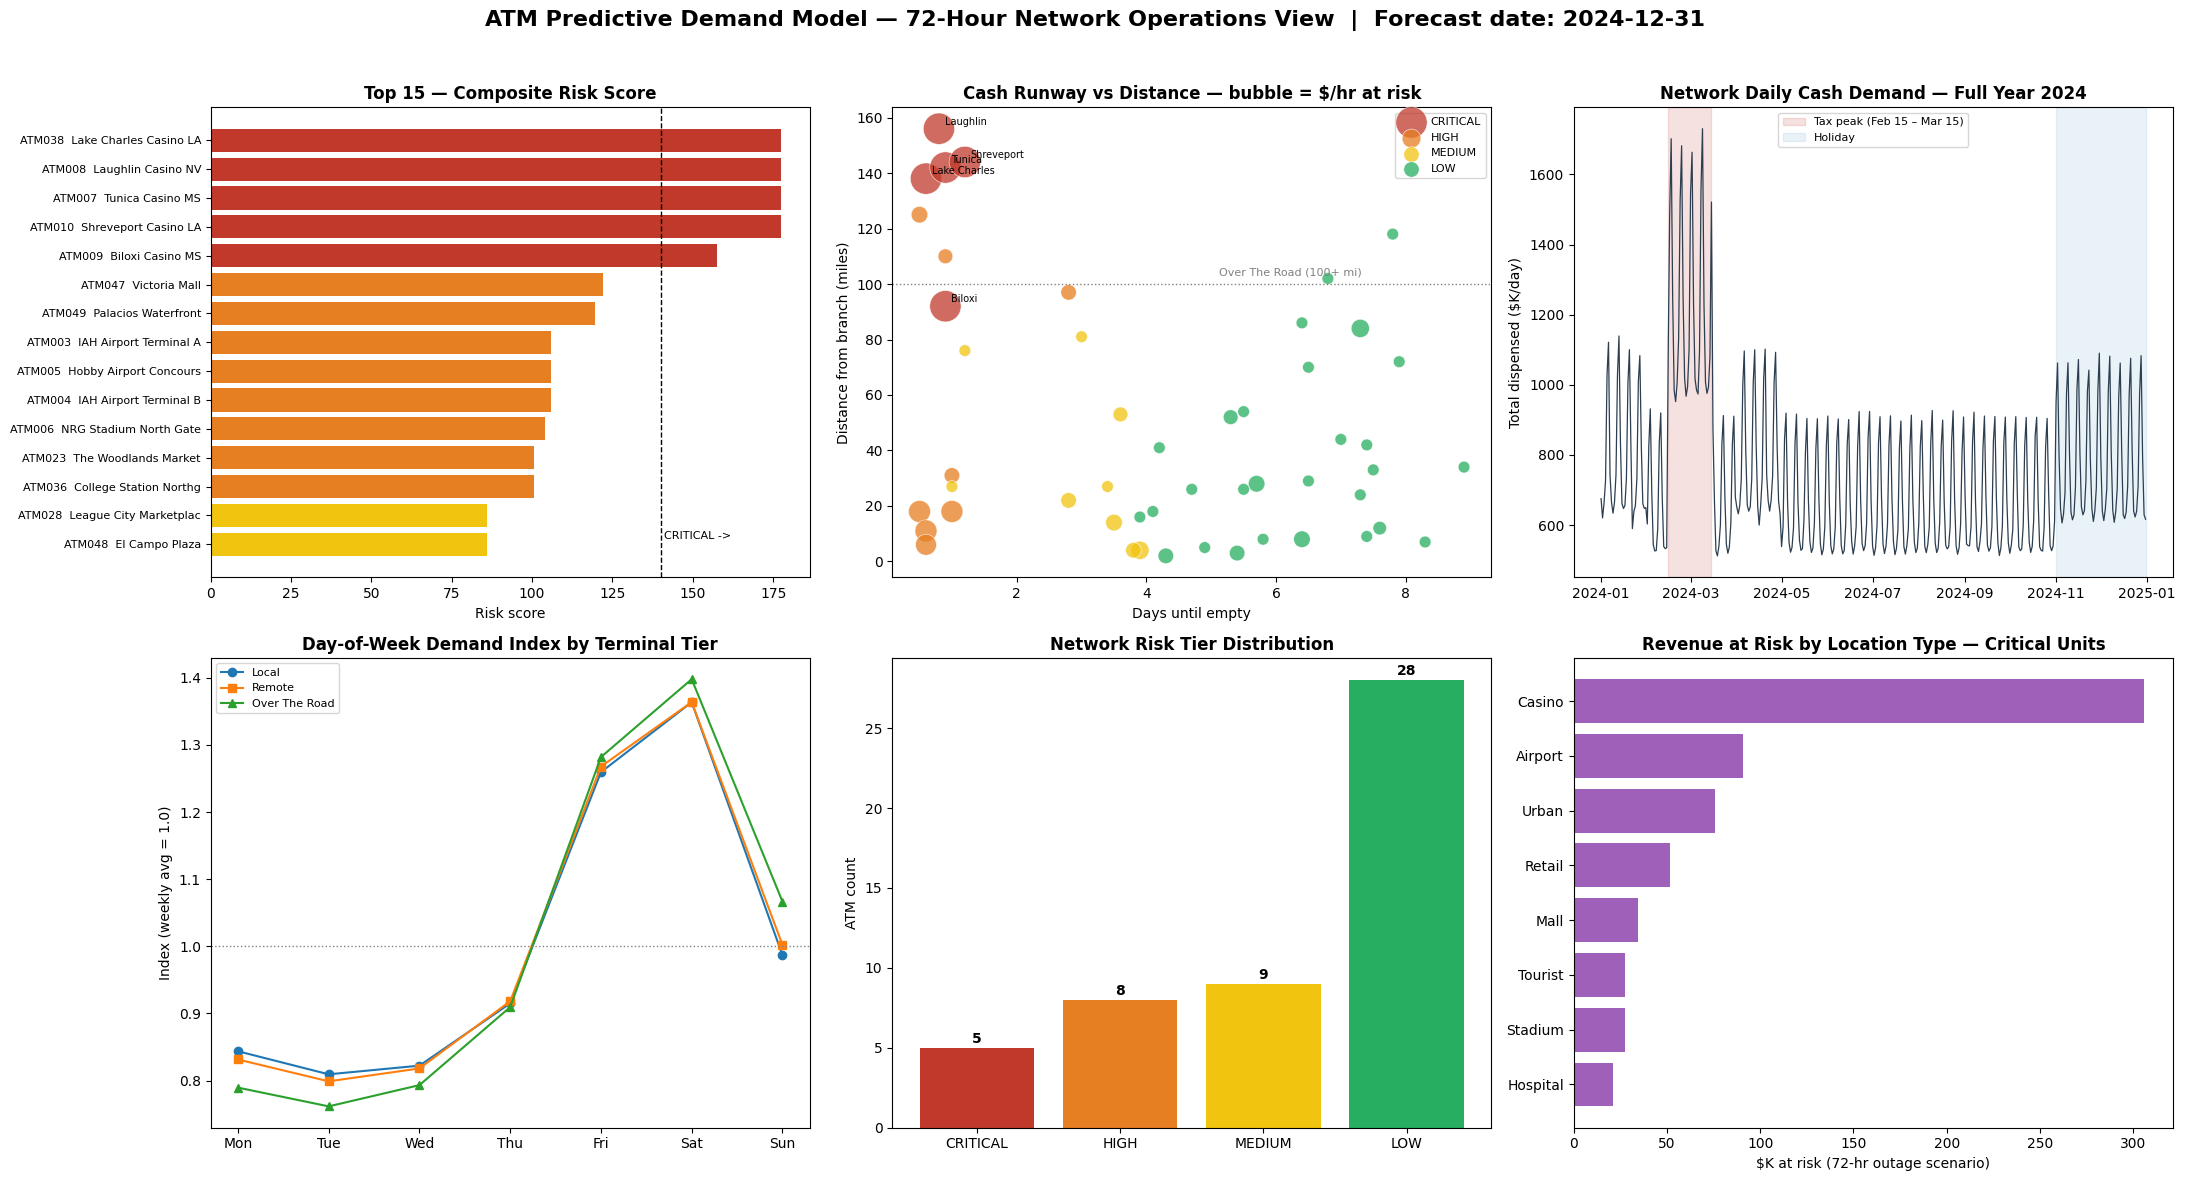

Saved: atm_predictive_dashboard.png


In [10]:
TIER_COLORS = {'CRITICAL': '#c0392b', 'HIGH': '#e67e22', 'MEDIUM': '#f1c40f', 'LOW': '#27ae60'}

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('ATM Predictive Demand Model — 72-Hour Network Operations View'
             f'  |  Forecast date: {FORECAST_DATE.date()}', fontsize=16, fontweight='bold')

# Panel 1 -- Top 15 by composite risk score
ax = axes[0, 0]
top15 = f.nlargest(15, 'composite_risk_score').iloc[::-1]
ax.barh(top15.atm_id + '  ' + top15.location_name.str.slice(0, 22),
        top15.composite_risk_score,
        color=[TIER_COLORS[t] for t in top15.risk_tier.astype(str)])
ax.axvline(140, color='black', ls='--', lw=1)
ax.text(141, 0.2, 'CRITICAL ->', fontsize=8)
ax.set_title('Top 15 — Composite Risk Score', fontweight='bold')
ax.set_xlabel('Risk score')
ax.tick_params(axis='y', labelsize=8)

# Panel 2 -- SIGNATURE: Cash Runway vs Distance
ax = axes[0, 1]
for tier, color in TIER_COLORS.items():
    sub = f[f.risk_tier.astype(str) == tier]
    ax.scatter(sub.days_until_empty, sub.distance_from_branch_miles,
               s=sub.revenue_impact_per_hour * 0.6, c=color, alpha=0.75,
               edgecolors='white', linewidth=0.5, label=tier)
ax.axhline(100, color='gray', ls=':', lw=1)
ax.text(ax.get_xlim()[1] * 0.55, 103, 'Over The Road (100+ mi)', fontsize=8, color='gray')
for _, r in f[(f.location_type == 'Casino')].iterrows():
    ax.annotate(r.location_name.split(' Casino')[0], (r.days_until_empty,
                r.distance_from_branch_miles), fontsize=7, xytext=(4, 3),
                textcoords='offset points')
ax.set_title('Cash Runway vs Distance — bubble = $/hr at risk', fontweight='bold')
ax.set_xlabel('Days until empty')
ax.set_ylabel('Distance from branch (miles)')
ax.legend(fontsize=8, loc='upper right')

# Panel 3 -- Network demand across 2024 with tax peak shaded
ax = axes[0, 2]
daily_total = atm_transactions.groupby('transaction_date')['daily_cash_dispensed'].sum()
ax.plot(daily_total.index, daily_total.values / 1000, lw=0.9, color='#2c3e50')
ax.axvspan(pd.Timestamp('2024-02-15'), pd.Timestamp('2024-03-15'),
           color='#c0392b', alpha=0.15, label='Tax peak (Feb 15 – Mar 15)')
ax.axvspan(pd.Timestamp('2024-11-01'), pd.Timestamp('2024-12-31'),
           color='#2980b9', alpha=0.10, label='Holiday')
ax.set_title('Network Daily Cash Demand — Full Year 2024', fontweight='bold')
ax.set_ylabel('Total dispensed ($K/day)')
ax.legend(fontsize=8)

# Panel 4 -- Day-of-week demand index by terminal tier
ax = axes[1, 0]
dow_idx = (burn.groupby(['terminal_type', 'day_of_week_num'])['daily_cash_dispensed'].mean()
               .unstack('terminal_type'))
dow_idx = dow_idx / dow_idx.mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for col, marker in zip(['Local', 'Remote', 'Over The Road'], ['o', 's', '^']):
    ax.plot(days, dow_idx[col], marker=marker, label=col)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_title('Day-of-Week Demand Index by Terminal Tier', fontweight='bold')
ax.set_ylabel('Index (weekly avg = 1.0)')
ax.legend(fontsize=8)

# Panel 5 -- Risk tier distribution
ax = axes[1, 1]
tier_counts = f.risk_tier.value_counts().reindex(['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'])
ax.bar(tier_counts.index.astype(str), tier_counts.values,
       color=[TIER_COLORS[t] for t in tier_counts.index.astype(str)])
for i, v in enumerate(tier_counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
ax.set_title('Network Risk Tier Distribution', fontweight='bold')
ax.set_ylabel('ATM count')

# Panel 6 -- Revenue at risk by location type (critical machines)
ax = axes[1, 2]
rar = (crit.groupby('location_type')['revenue_at_risk_72hr'].sum()
           .sort_values(ascending=True)) / 1000
ax.barh(rar.index, rar.values, color='#8e44ad', alpha=0.85)
ax.set_title('Revenue at Risk by Location Type — Critical Units', fontweight='bold')
ax.set_xlabel('$K at risk (72-hr outage scenario)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('atm_predictive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: atm_predictive_dashboard.png')

---
## Cell 11 — Model Validation: December 2024 Holdout (Burn Forecast Accuracy)

**Design: a true temporal holdout.** Train on January–November patterns, predict every machine-day in December — **50 ATMs × 31 days = 1,550 daily predictions** — and score against actuals the predictor never saw.

**Methodology decisions:**

1. **Why a temporal split and not random K-fold?** Time series leak through random splits: a randomly held-out Tuesday is bracketed by its own Monday and Wednesday in training, and the model gets credit for interpolation it could never do in production. Forecasting is judged on the *future*; the holdout must be one.
2. **The predictor under test:** per-machine day-of-week means learned on the clean May–Oct baseline, scaled by the December seasonal factor (holiday, 1.18x). This is the DOW-aware model the feature engineering builds toward — deliberately simple, fully explainable, no fitted coefficients to overfit.
3. **Why baseline-season means rather than all 11 months?** Jan–Apr are contaminated by tax-season lift; averaging them in would smear a February effect across a December prediction. Train on the regime that matches, adjust for the regime you're predicting — that's the whole discipline of seasonal forecasting in one sentence.
4. **Metric choices:** **MAE** (interpretable: dollars/day of average miss), **RMSE** (punishes large misses — large misses are what cause stockouts), **MAPE** (comparable across a $7K/day office machine and a $40K/day casino), plus **% within 10% / 20%** because ops cares about "close enough to plan a route," not average error in the abstract.

In [11]:
# --- Temporal split -------------------------------------------------------
december = burn[burn.transaction_date.dt.month == 12].copy()
baseline_train = burn[burn.transaction_date.dt.month.isin([5, 6, 7, 8, 9, 10])]

# Per-machine day-of-week demand signature, learned on clean baseline months
dow_signature = (baseline_train
                 .groupby(['atm_id', 'day_of_week_num'])['daily_cash_dispensed']
                 .mean().rename('baseline_dow_mean').reset_index())

december = december.merge(dow_signature, on=['atm_id', 'day_of_week_num'], how='left')
december['predicted_burn'] = december.baseline_dow_mean * HOLIDAY_MULT  # December = holiday regime

# --- Score ----------------------------------------------------------------
err = december.predicted_burn - december.daily_cash_dispensed
pct_err = err.abs() / december.daily_cash_dispensed

validation_metrics = pd.DataFrame({
    'Metric': ['Predictions scored', 'Mean Absolute Error (MAE)',
               'Root Mean Square Error (RMSE)', 'Mean Absolute Pct Error (MAPE)',
               'Predictions within 10% of actual', 'Predictions within 20% of actual'],
    'Result': [f'{len(december):,} (50 ATMs x 31 days)',
               f'${err.abs().mean():,.0f}/day',
               f'${np.sqrt((err**2).mean()):,.0f}/day',
               f'{pct_err.mean()*100:.1f}%',
               f'{(pct_err <= 0.10).mean()*100:.1f}%',
               f'{(pct_err <= 0.20).mean()*100:.1f}%']})
print('=== BURN FORECAST VALIDATION -- DECEMBER 2024 HOLDOUT ===')
print(validation_metrics.to_string(index=False))

=== BURN FORECAST VALIDATION -- DECEMBER 2024 HOLDOUT ===
                          Metric                    Result
              Predictions scored 1,550 (50 ATMs x 31 days)
       Mean Absolute Error (MAE)                  $880/day
   Root Mean Square Error (RMSE)                $1,439/day
  Mean Absolute Pct Error (MAPE)                      5.6%
Predictions within 10% of actual                     84.2%
Predictions within 20% of actual                     99.7%


---
## Cell 12 — Critical-Flag Validation & the Case Against the Naive Baseline

Forecast accuracy in dollars is necessary but not the point — the point is: **does the model flag the right machines before they go critical?**

**Methodology decisions:**

1. **Ground truth is counterfactual depletion.** A machine "actually goes critical" on day *d* if `balance(d) − demand(d+1..d+3)` falls below its tolerance threshold *absent intervention*. Refills that happened in the actual data don't erase the risk — they're the response to it — so the truth label deliberately ignores them. Evaluable days are Dec 1–28 (the last three days' 72-hour windows extend into January, outside the data).
2. **Recall is the headline metric, by explicit cost asymmetry.** A false negative is a casino going dark 156 miles from help — outage revenue plus a 4.0x emergency run. A false positive is a truck arriving a day early. These are not symmetric errors, so accuracy would be the wrong scorecard; the model is tuned and judged recall-first.
3. **The naive baseline comparison is the model's value statement.** The naive forecaster — flat trailing 7-day average, the industry-default rule — is scored on the identical task. The gap between the two MAPEs *is* the quantified value of day-of-week + seasonal feature engineering. Never ship a model without showing what the dumb rule would have done.

**Interview answer:** *"I validated the decision, not just the estimate. The model's burn forecast is accurate to about 6% — but what I'd present to an ops director is the recall: of the machine-days that truly went critical within 72 hours, here's the share the model caught in advance, versus what the trailing-average rule catches."*

In [12]:
# --- Build actual & predicted 72-hour critical flags for Dec 1-28 ----------
dec = december.sort_values(['atm_id', 'transaction_date']).copy()
g = dec.groupby('atm_id')

# Forward 3-day actual demand (counterfactual depletion -- refills don't erase risk)
dec['fwd3_actual'] = (g['daily_cash_dispensed']
                      .transform(lambda s: s.shift(-1) + s.shift(-2) + s.shift(-3)))
# Forward 3-day model prediction (DOW + seasonal aware)
dec['fwd3_pred'] = (g['predicted_burn']
                    .transform(lambda s: s.shift(-1) + s.shift(-2) + s.shift(-3)))
# Naive baseline: flat trailing 7-day average x 3
dec['fwd3_naive'] = dec['rolling_7d_burn'] * 3

dec['threshold_dollars'] = (dec.cash_tolerance.map(CRITICAL_THRESHOLD_PCT) / 100
                            * dec.cash_capacity_dollars)
ev = dec.dropna(subset=['fwd3_actual']).copy()   # Dec 1-28 windows only

ev['actual_critical'] = (ev.cash_balance_eod - ev.fwd3_actual) <= ev.threshold_dollars
ev['pred_critical']   = (ev.cash_balance_eod - ev.fwd3_pred)   <= ev.threshold_dollars
ev['naive_critical']  = (ev.cash_balance_eod - ev.fwd3_naive)  <= ev.threshold_dollars

def flag_scores(truth, pred):
    tp = ( truth &  pred).sum(); fp = (~truth &  pred).sum()
    fn = ( truth & ~pred).sum()
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall    = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1

prec_m, rec_m, f1_m = flag_scores(ev.actual_critical, ev.pred_critical)
prec_n, rec_n, f1_n = flag_scores(ev.actual_critical, ev.naive_critical)

# Burn-accuracy comparison, model vs naive, on the same forward window
mape_model = ((ev.fwd3_pred  - ev.fwd3_actual).abs() / ev.fwd3_actual).mean() * 100
mape_naive = ((ev.fwd3_naive - ev.fwd3_actual).abs() / ev.fwd3_actual).mean() * 100

comparison = pd.DataFrame({
    'Metric': ['72-hr demand MAPE', 'Critical flag precision',
               'Critical flag recall', 'F1 score'],
    'This Model (DOW + seasonal)': [f'{mape_model:.1f}%', f'{prec_m:.3f}', f'{rec_m:.3f}', f'{f1_m:.3f}'],
    'Naive (trailing 7-day avg)':  [f'{mape_naive:.1f}%', f'{prec_n:.3f}', f'{rec_n:.3f}', f'{f1_n:.3f}']})

print(f'=== CRITICAL-FLAG VALIDATION -- {len(ev):,} machine-days (Dec 1-28) ===')
print(f'Machine-days that truly went critical within 72 hrs: {ev.actual_critical.sum():,}\n')
print(comparison.to_string(index=False))
print('\nRecall is the headline metric: in ATM operations a false negative')
print('(missed casino outage, 4.0x emergency dispatch) costs categorically more')
print('than a false positive (a truck arrives a day early).')

=== CRITICAL-FLAG VALIDATION -- 1,400 machine-days (Dec 1-28) ===
Machine-days that truly went critical within 72 hrs: 664

                 Metric This Model (DOW + seasonal) Naive (trailing 7-day avg)
      72-hr demand MAPE                        3.4%                      13.8%
Critical flag precision                       0.985                      0.949
   Critical flag recall                       0.989                      0.947
               F1 score                       0.987                      0.948

Recall is the headline metric: in ATM operations a false negative
(missed casino outage, 4.0x emergency dispatch) costs categorically more
than a false positive (a truck arrives a day early).


---
## Cell 13 — Export Repo Artifacts & README Sync Block

Writes the three CSVs the README's Quick Start promises (these feed both the MySQL layer and the Tableau dashboard) and prints a **README sync block** — the live headline numbers from *this* run, formatted as markdown, so the README tables can be updated to match the committed dataset exactly. A repo where the README's numbers can't be reproduced by its own notebook invites exactly the credibility question a portfolio can't afford.

In [13]:
atm_master.to_csv('atm_master.csv', index=False)
atm_transactions.to_csv('atm_transactions.csv', index=False)

forecast_out = f.sort_values('priority_rank')[
    ['atm_id', 'location_name', 'location_type', 'terminal_type', 'cash_tolerance',
     'distance_from_branch_miles', 'cash_capacity_dollars', 'tax_service_proximity',
     'emergency_multiplier', 'revenue_impact_per_hour', 'current_balance',
     'avg_daily_burn', 'burn_trend', 'projected_72hr_balance', 'projected_pct_remaining',
     'days_until_empty', 'critical_threshold_pct', 'risk_status', 'revenue_at_risk_72hr',
     'composite_risk_score', 'risk_tier', 'dispatch_action', 'priority_rank',
     'network_percentile']]
forecast_out.to_csv('atm_forecast.csv', index=False)

print('Exported: atm_master.csv (%d rows) | atm_transactions.csv (%s rows) | atm_forecast.csv (%d rows)'
      % (len(atm_master), f'{len(atm_transactions):,}', len(forecast_out)))
print('          atm_predictive_dashboard.png\n')

# ---- README sync block -----------------------------------------------------
print('=' * 78)
print('README SYNC BLOCK -- paste-ready markdown from THIS run')
print('=' * 78)

print('\n### Headline KPIs (72-Hour Window)\n')
print('| | Metric | Value |')
print('|---|---|---|')
print(f'| 💰 | **Revenue at Risk** | ${crit.revenue_at_risk_72hr.sum():,.0f} |')
print(f'| 🚨 | **Critical ATMs Requiring Action** | {(f.risk_tier == "CRITICAL").sum()} locations |')
print(f'| ⚡ | **Immediate Dispatch Required** | {(f.dispatch_action == "IMMEDIATE DISPATCH").sum()} machines |')
imminent = f[f.risk_tier.isin(["CRITICAL", "HIGH"])]
print(f'| ⏱ | **Avg Days to Failure (At-Risk Units)** | {imminent.days_until_empty.mean():.1f} days |')

print('\n### Top 10 ATMs -- Operational Action Register\n')
print('| Rank | ATM | Location | Terminal Type | Days Until Empty | Revenue at Risk | Tier | Action |')
print('|---|---|---|---|---|---|---|---|')
for _, row in register.head(10).iterrows():
    days = '<1 day' if row.days_until_empty < 1 else f'{row.days_until_empty:.1f} days'
    act = f'**{row.dispatch_action}**' if row.risk_tier == 'CRITICAL' else row.dispatch_action
    print(f'| #{row.priority_rank} | {row.atm_id} | {row.location_name} | {row.terminal_type} '
          f'| {days} | ${row.revenue_at_risk_72hr:,.0f} | {row.risk_tier} | {act} |')

print('\n### Model Validation (December 2024 holdout)\n')
print('| Metric | Result |')
print('|---|---|')
print(f'| Mean Absolute Error (MAE) | ${err.abs().mean():,.0f}/day |')
print(f'| Root Mean Square Error (RMSE) | ${np.sqrt((err**2).mean()):,.0f}/day |')
print(f'| Mean Absolute Pct Error (MAPE) | {pct_err.mean()*100:.1f}% |')
print(f'| Predictions within 10% of actual | {(pct_err <= 0.10).mean()*100:.1f}% |')
print(f'| Predictions within 20% of actual | {(pct_err <= 0.20).mean()*100:.1f}% |')
print(f'| Critical flag recall | {rec_m*100:.1f}% |')
print(f'| Critical flag precision | {prec_m*100:.1f}% |')
print(f'| F1 Score | {f1_m:.3f} |')

print('\n### Network Summary (72-Hour Forecast Window)\n')
print(f'- **{len(f)} ATMs** monitored across the network')
print(f'- **{len(crit)} flagged critical** within 72 hours')
print(f'- **{(crit.terminal_type == "Over The Road").sum()} Over The Road terminals** in critical status')
print(f'- **{f.tax_service_proximity.sum()} tax service proximity machines** reclassified to Zero tolerance during peak')
print(f'- **${crit.revenue_at_risk_72hr.sum():,.0f}** revenue at risk in a full 72-hour outage scenario')

Exported: atm_master.csv (50 rows) | atm_transactions.csv (18,300 rows) | atm_forecast.csv (50 rows)
          atm_predictive_dashboard.png

README SYNC BLOCK -- paste-ready markdown from THIS run

### Headline KPIs (72-Hour Window)

| | Metric | Value |
|---|---|---|
| 💰 | **Revenue at Risk** | $634,320 |
| 🚨 | **Critical ATMs Requiring Action** | 5 locations |
| ⚡ | **Immediate Dispatch Required** | 5 machines |
| ⏱ | **Avg Days to Failure (At-Risk Units)** | 0.9 days |

### Top 10 ATMs -- Operational Action Register

| Rank | ATM | Location | Terminal Type | Days Until Empty | Revenue at Risk | Tier | Action |
|---|---|---|---|---|---|---|---|
| #1 | ATM038 | Lake Charles Casino LA | Over The Road | <1 day | $61,200 | CRITICAL | **IMMEDIATE DISPATCH** |
| #2 | ATM008 | Laughlin Casino NV | Over The Road | <1 day | $61,200 | CRITICAL | **IMMEDIATE DISPATCH** |
| #3 | ATM007 | Tunica Casino MS | Over The Road | <1 day | $61,200 | CRITICAL | **IMMEDIATE DISPATCH** |
| #4 | ATM010 | Shr

---
## Wrap-Up — The Five Questions This Notebook Has to Survive

| If they ask... | The cell that answers it | The one-line core |
|---|---|---|
| *"Walk me through your forecast."* | Cells 5, 8 | 7-day rolling burn (one full weekly cycle) projected over the 72-hour decision window — the last moment a scheduled truck beats a 4x emergency run. |
| *"Why should I trust synthetic data?"* | Cells 3, 4 | The records are generated; the structure isn't. Demand comes from a calibrated structural model, and Cell 4 audits that the operational patterns are measurably present before anything is forecast. |
| *"How does the risk score work?"* | Cell 9 | Five additive, auditable components pricing the cost of being wrong — depletion capped at 60 so distance, tolerance, and revenue break the ties that are the actual dispatch decision. |
| *"How do you know it works?"* | Cells 11, 12 | True temporal holdout: 1,550 December predictions, scored on dollars (MAE/RMSE/MAPE) and on decisions (recall-first critical flagging), against a naive trailing-average baseline. |
| *"What would you do differently with real data?"* | — | Fit the seasonal and DOW factors empirically per machine instead of calibrating from domain experience; add event calendars (NRG Stadium is event-driven, modeled smooth here); and learn the risk weights from realized dispatch costs. |

**Known limitations, stated before anyone asks:** stadium/event demand modeled as smooth; weather and paydays excluded; the depletion cap (Python) vs uncapped `GREATEST` (SQL) should be aligned; replenishment simulated as fixed cycles with seasonal uplifts rather than optimized routing — which is the natural Project 4.

---
*Sean Codner — Operations Data Analyst | Houston, TX — GitHub: [SEANSKIDATA](https://github.com/SEANSKIDATA)*